In [2]:
# --- 1. SETUP AND INITIALIZATION ---

# --- Step 1.1: Import Libraries ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Step 1.2: Configure device (GPU or CPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Step 1.3: Define paths to data directories ---
data_dir = 'data'
train_dir = os.path.join(data_dir, 'seg_train')
test_dir = os.path.join(data_dir, 'seg_test')

# --- Step 1.4: Get class names from folder names ---
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

Using device: cuda
Found 6 classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [3]:
# --- 2. DATA PREPARATION AND LOADING ---

# --- Step 2.1: Define data transformations for training and testing sets ---
# We apply different transformations to the training and test data.
# For training data, we use data augmentation (RandomResizedCrop, RandomHorizontalFlip)
# to make our model more robust.
# For test data, we just resize and center crop.

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- Step 2.2: Create datasets using ImageFolder ---
# ImageFolder is a PyTorch class that automatically finds images in subfolders
# and assigns the correct labels based on the folder name.
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

# --- Step 2.3: Create DataLoaders for the datasets ---
# DataLoaders are responsible for shuffling the data and creating batches.
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=4),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=4)
}

# Get the size of the datasets
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
print(f"Training set size: {dataset_sizes['train']}")
print(f"Test set size: {dataset_sizes['test']}")

print("\nDataLoaders created successfully.")

Training set size: 14034
Test set size: 3000

DataLoaders created successfully.


In [4]:
# --- 3. MODEL SETUP (TRANSFER LEARNING) ---

# --- Step 3.1: Load a pre-trained ResNet18 model ---
# We load the ResNet18 model that was pre-trained on the ImageNet dataset.
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# --- Step 3.2: Freeze all the parameters in the pre-trained model ---
# We do not want to update the weights of the feature extractor part of the network.
for param in model_ft.parameters():
    param.requires_grad = False

# --- Step 3.3: Replace the final classification layer (the "head") ---
# The original ResNet18 has a final layer that outputs 1000 features (for 1000 ImageNet classes).
# We need to replace it with a new layer that outputs num_classes (6 in our case).

# Get the number of input features for the final layer
num_ftrs = model_ft.fc.in_features

# Create a new, untrained final layer
# nn.Linear(num_ftrs, num_classes) is a standard fully connected layer.
model_ft.fc = nn.Linear(num_ftrs, num_classes)

# --- Step 3.4: Move the model to the correct device (GPU/CPU) ---
model_ft = model_ft.to(device)

print("Pre-trained ResNet18 model loaded and modified for our task.")
# Print the model architecture to see the new final layer
# print(model_ft)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\takze/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


Pre-trained ResNet18 model loaded and modified for our task.


In [5]:
# --- 4. TRAINING THE MODEL ---

# --- Step 4.1: Define the Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss()

# We only want to optimize the parameters of the final, newly added layer.
# We filter the model's parameters to get only those with requires_grad = True.
params_to_update = model_ft.parameters()
print("Params to learn:")
params_to_update_list = []
for name, param in model_ft.named_parameters():
    if param.requires_grad == True:
        params_to_update_list.append(param)
        print("\t", name)

optimizer_ft = optim.Adam(params_to_update_list, lr=0.001)

# --- Step 4.2: The Training Loop ---
# This is a standard PyTorch training loop.
def train_model(model, criterion, optimizer, num_epochs=10):
    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                # Track history only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    print("--- Training Finished ---")
    return model

# --- Step 4.3: Start the training ---
model_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=10)

Params to learn:
	 fc.weight
	 fc.bias

--- Starting Training ---
Epoch 1/10
----------
train Loss: 0.6232 Acc: 0.7794
test Loss: 0.3088 Acc: 0.8930
Epoch 2/10
----------
train Loss: 0.4319 Acc: 0.8400
test Loss: 0.2666 Acc: 0.8993
Epoch 3/10
----------
train Loss: 0.4157 Acc: 0.8420
test Loss: 0.2700 Acc: 0.9023
Epoch 4/10
----------
train Loss: 0.4041 Acc: 0.8495
test Loss: 0.2585 Acc: 0.9047
Epoch 5/10
----------
train Loss: 0.4067 Acc: 0.8441
test Loss: 0.2653 Acc: 0.9037
Epoch 6/10
----------
train Loss: 0.4017 Acc: 0.8502
test Loss: 0.2572 Acc: 0.9040
Epoch 7/10
----------
train Loss: 0.3982 Acc: 0.8494
test Loss: 0.2753 Acc: 0.9030
Epoch 8/10
----------
train Loss: 0.4006 Acc: 0.8498
test Loss: 0.2903 Acc: 0.8980
Epoch 9/10
----------
train Loss: 0.3869 Acc: 0.8558
test Loss: 0.2581 Acc: 0.9113
Epoch 10/10
----------
train Loss: 0.3828 Acc: 0.8582
test Loss: 0.2610 Acc: 0.9093
--- Training Finished ---


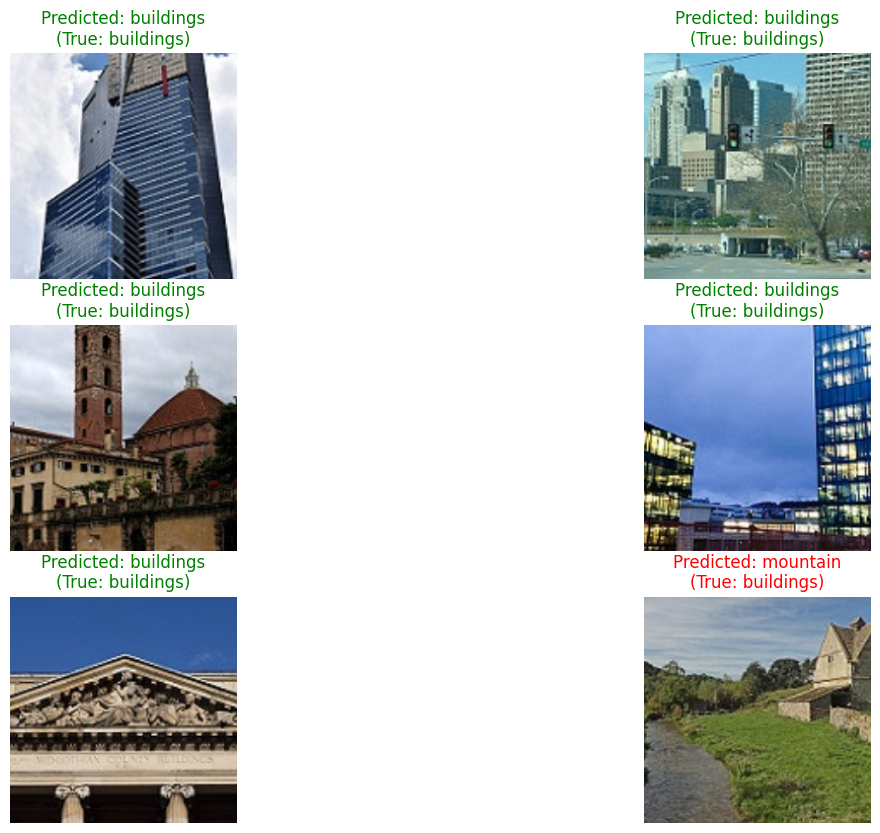

In [6]:
# --- 5. VISUALIZE MODEL PREDICTIONS ---

def visualize_model(model, num_images=6):
    """A function to display predictions for a few images."""
    was_training = model.training
    model.eval()
    images_so_far = 0
    
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                
                # Get the predicted class name and true class name
                pred_class = class_names[preds[j]]
                true_class = class_names[labels[j]]
                
                # Set the title color to green for correct predictions and red for incorrect ones
                title_color = 'green' if pred_class == true_class else 'red'
                ax.set_title(f'Predicted: {pred_class}\n(True: {true_class})', color=title_color)

                # Un-normalize and display the image
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    # --- SAVE THE FIGURE ---
                    plt.savefig('images/model_predictions.png', bbox_inches='tight')
                    return
        model.train(mode=was_training)

# --- Run the visualization function ---
visualize_model(model_ft)